### importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib           
import quantstats as qs   
import os
import certifi

# Force curl (used by yfinance/pynance) to use Python's trusted CA certificates
os.environ['CURL_CA_BUNDLE'] = certifi.where()

# Now import the rest of your libraries
import pynance as py
import yfinance as yf

# Make plots a bit nicer
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 6)

### Load Data

In [2]:
# Load stock data
df = pd.read_csv(r"C:\Users\Administrator\Downloads\challenge-week1\challenge-week1\data\META.csv")

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set datetime as index
df = df.set_index('Date')

df.head()


,Close,High,Low,Open,Volume
Date,,,,,
2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400
2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700
2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600
2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000
2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200


### Calculate Technical Indicators (TA-Lib)

#### Simple Moving Average (SMA)

In [3]:
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)

#### Exponential Moving Average (EMA)

In [4]:
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

#### Relative Strength Index (RSI)

In [5]:
df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)

#### MACD

In [6]:
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'], 
    fastperiod=12, 
    slowperiod=26, 
    signalperiod=9
)


#### Bollinger Bands

In [7]:
df['BB_upper'], df['BB_middle'], df['BB_lower'] = talib.BBANDS(
    df['Close'], 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2
)


### Visualizations

#### Plot Close Price + SMA / EMA

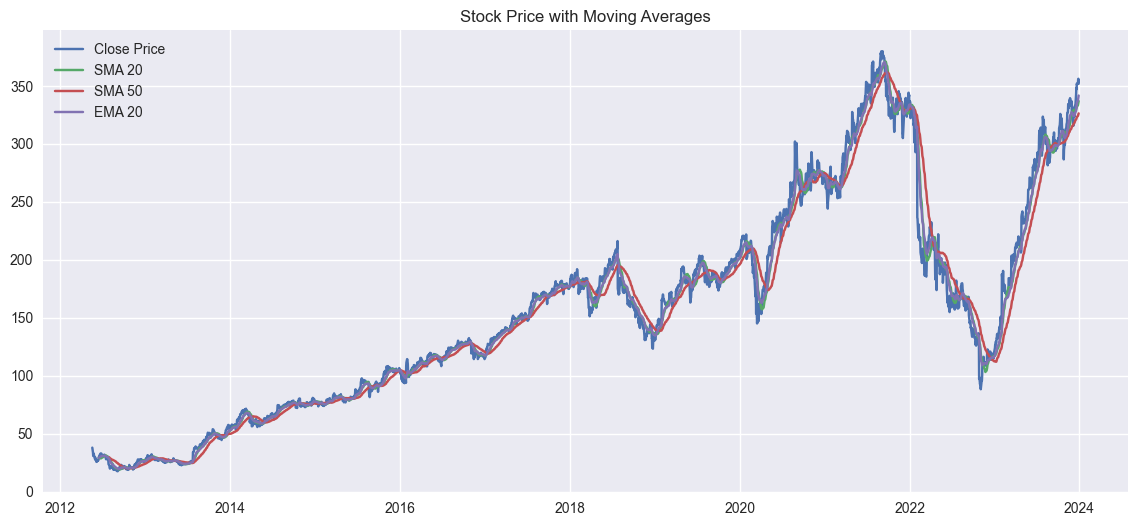

In [8]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['SMA_50'], label='SMA 50')
plt.plot(df['EMA_20'], label='EMA 20')
plt.title("Stock Price with Moving Averages")
plt.legend()
plt.show()


#### RSI Plot

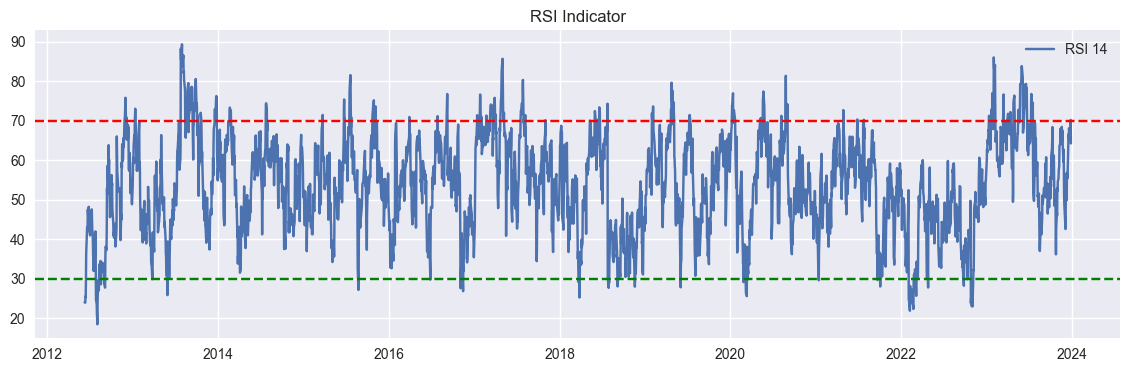

In [9]:
plt.figure(figsize=(14,4))
plt.plot(df['RSI_14'], label='RSI 14')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title("RSI Indicator")
plt.legend()
plt.show()


#### MACD Plot

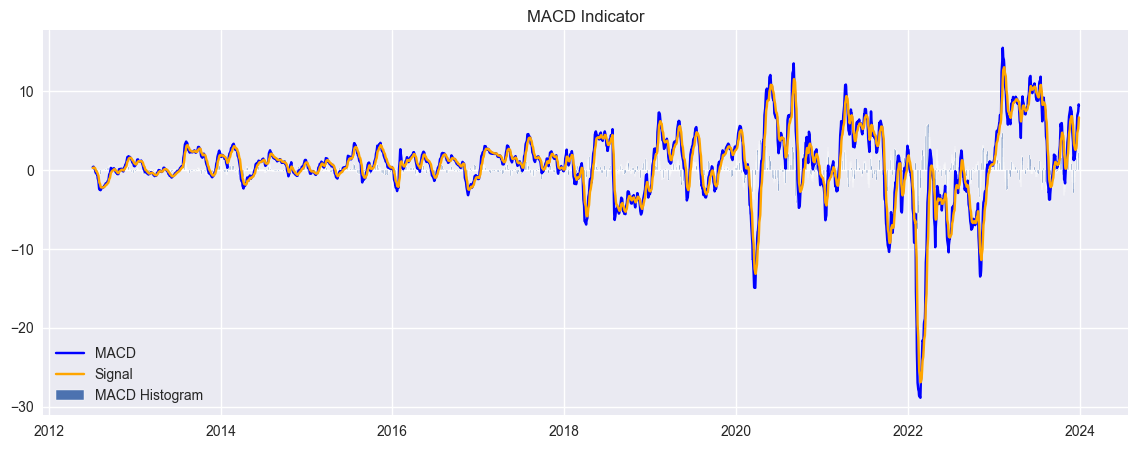

In [10]:
plt.figure(figsize=(14,5))
plt.plot(df['MACD'], label='MACD', color='blue')
plt.plot(df['MACD_signal'], label='Signal', color='orange')
plt.bar(df.index, df['MACD_hist'], label='MACD Histogram')
plt.title("MACD Indicator")
plt.legend()
plt.show()


#### Bollinger Bands

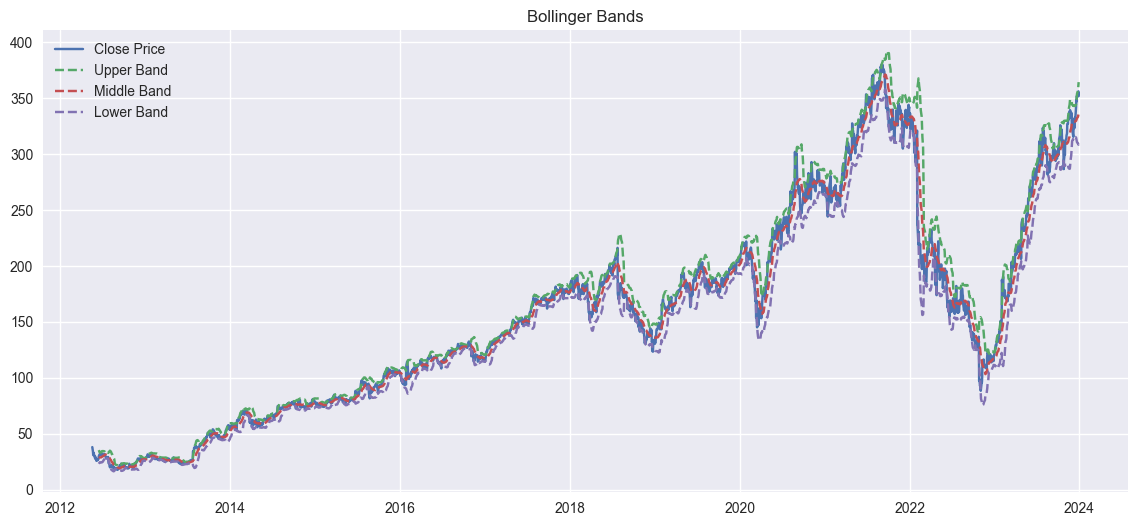

In [11]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['BB_upper'], label='Upper Band', linestyle='--')
plt.plot(df['BB_middle'], label='Middle Band', linestyle='--')
plt.plot(df['BB_lower'], label='Lower Band', linestyle='--')
plt.title("Bollinger Bands")
plt.legend()
plt.show()


### Quick look at price and volume

              count          mean           std           min           25%  \
Close        2923.0  1.567274e+02  9.036877e+01  1.762137e+01  8.027512e+01   
High         2923.0  1.586905e+02  9.147074e+01  1.815806e+01  8.097084e+01   
Low          2923.0  1.546851e+02  8.922298e+01  1.744247e+01  7.966389e+01   
Open         2923.0  1.566536e+02  9.030883e+01  1.796922e+01  8.027513e+01   
Volume       2923.0  3.060615e+07  2.637157e+07  5.467500e+06  1.633730e+07   
SMA_20       2904.0  1.565248e+02  8.944442e+01  1.914150e+01  8.047999e+01   
SMA_50       2874.0  1.562922e+02  8.812121e+01  2.005238e+01  8.067973e+01   
EMA_20       2904.0  1.565396e+02  8.930659e+01  1.956597e+01  8.045085e+01   
RSI_14       2909.0  5.381482e+01  1.199040e+01  1.851176e+01  4.556590e+01   
MACD         2890.0  7.316036e-01  4.541949e+00 -2.886835e+01 -7.007792e-01   
MACD_signal  2890.0  7.226952e-01  4.317168e+00 -2.689685e+01 -6.552844e-01   
MACD_hist    2890.0  8.908437e-03  1.246525e+00 -9.5

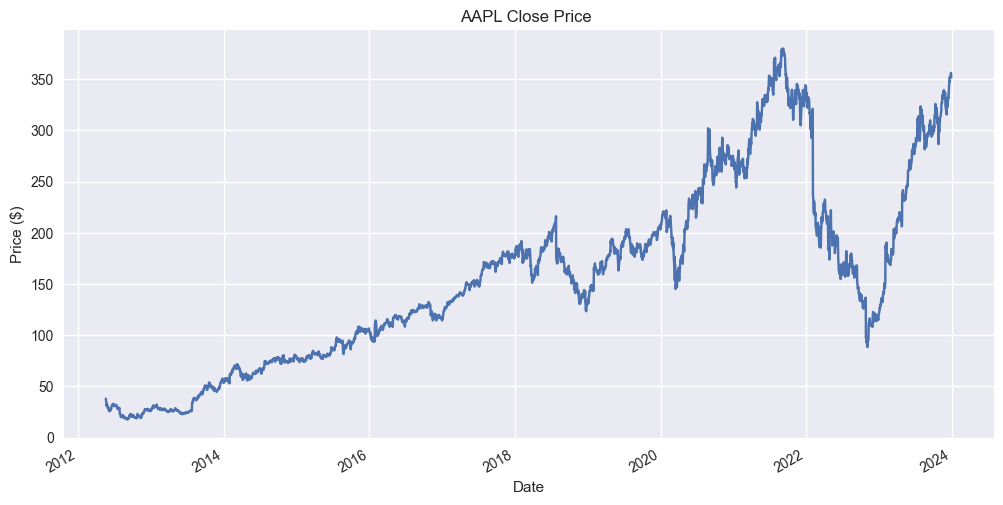

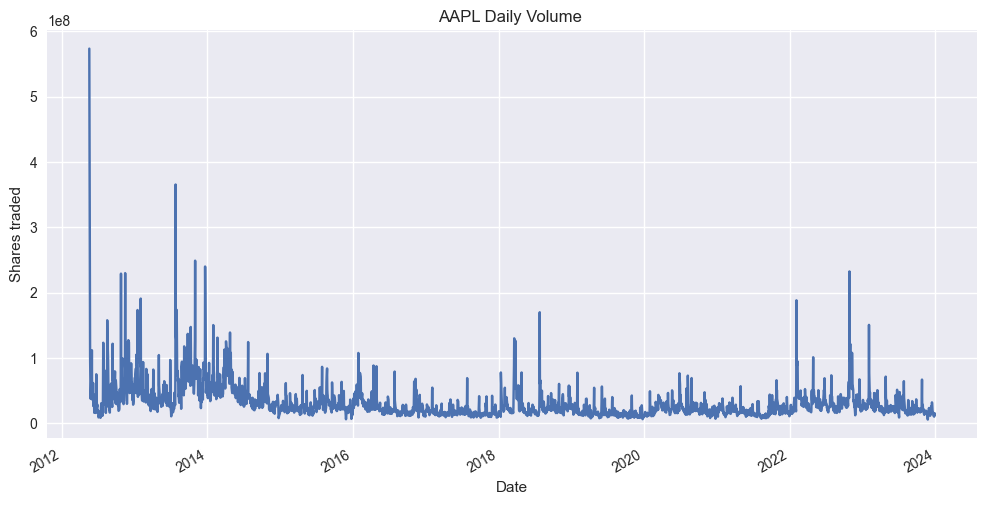

In [12]:
print(df.describe().T)

# Close price chart
df["Close"].plot(title="AAPL Close Price ")
plt.ylabel("Price ($)")
plt.show()

# Volume chart
df["Volume"].plot(title="AAPL Daily Volume ")
plt.ylabel("Shares traded")
plt.show()


### Compute technical indicators with TA-Lib

In [13]:
# Use 'Adj Close' if available, otherwise 'Close'
if "Adj Close" in df.columns:
    price = df["Adj Close"]
else:
    price = df["Close"]

# --- Moving Averages ---
df["SMA_20"] = talib.SMA(price, timeperiod=20)
df["SMA_50"] = talib.SMA(price, timeperiod=50)
df["EMA_20"] = talib.EMA(price, timeperiod=20)

# --- RSI ---
df["RSI_14"] = talib.RSI(price, timeperiod=14)

# --- MACD ---
df["MACD"], df["MACD_signal"], df["MACD_hist"] = talib.MACD(
    price, fastperiod=12, slowperiod=26, signalperiod=9
)


df.tail()


,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI_14,MACD,MACD_signal,MACD_hist,BB_upper,BB_middle,BB_lower
Date,,,,,,,,,,,,,,,
2023-12-22,351.224823,355.011477,349.068105,353.401377,11772800,332.302945,323.317843,335.581703,67.333885,6.945367,4.729907,2.215461,354.085026,332.302945,310.520864
2023-12-26,352.655975,354.792827,351.284456,352.814999,9898600,333.303278,324.115724,337.207824,68.187000,7.436800,5.271285,2.165514,356.825215,333.303278,309.781340
2023-12-27,355.637543,356.800387,353.132994,353.888347,13207900,334.239505,324.844828,338.963036,69.947874,7.974921,5.812012,2.162908,359.674389,334.239505,308.804621
2023-12-28,356.124634,359.682686,355.617749,357.496184,11798800,335.537503,325.527023,340.597473,70.237702,8.344500,6.318510,2.025990,362.605290,335.537503,308.469716
2023-12-29,351.791290,357.794292,349.664418,356.790470,14987100,336.869788,326.262290,341.663551,64.296803,8.193282,6.693464,1.499818,364.379857,336.869788,309.359718


### Price + SMA + Bollinger Bands

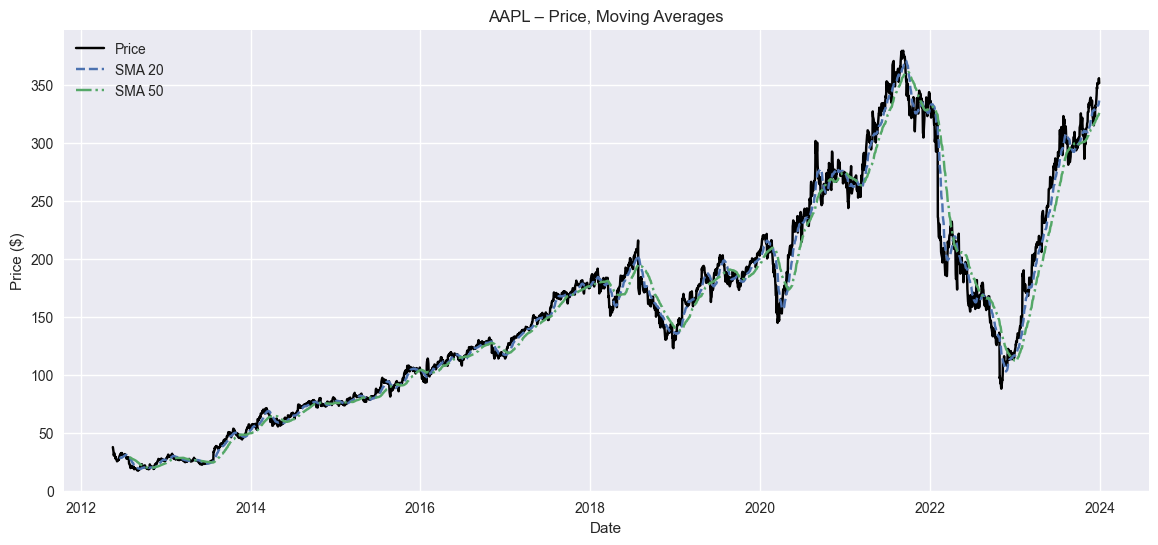

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, price, label="Price", color="black")
ax.plot(df.index, df["SMA_20"], label="SMA 20", linestyle="--")
ax.plot(df.index, df["SMA_50"], label="SMA 50", linestyle="-.")


ax.set_title("AAPL – Price, Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend()
plt.show()


### RSI – Overbought / Oversold

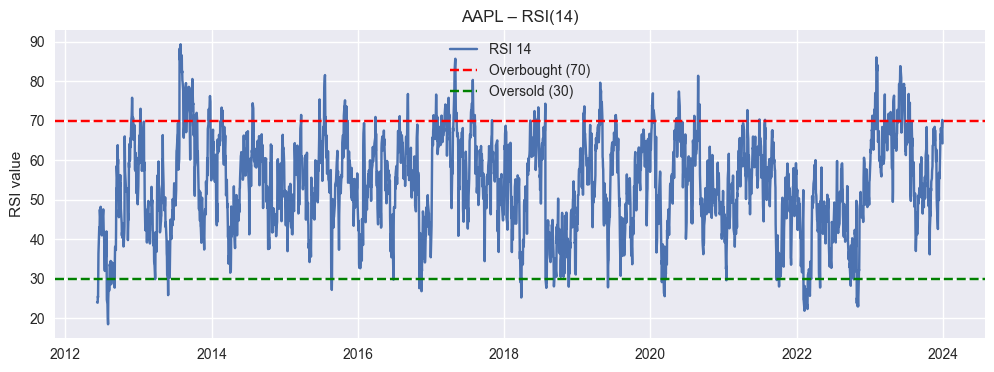

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["RSI_14"], label="RSI 14")
ax.axhline(70, color="red", linestyle="--", label="Overbought (70)")
ax.axhline(30, color="green", linestyle="--", label="Oversold (30)")

ax.set_title("AAPL – RSI(14)")
ax.set_ylabel("RSI value")
ax.legend()
plt.show()


### MACD – Trend & momentum

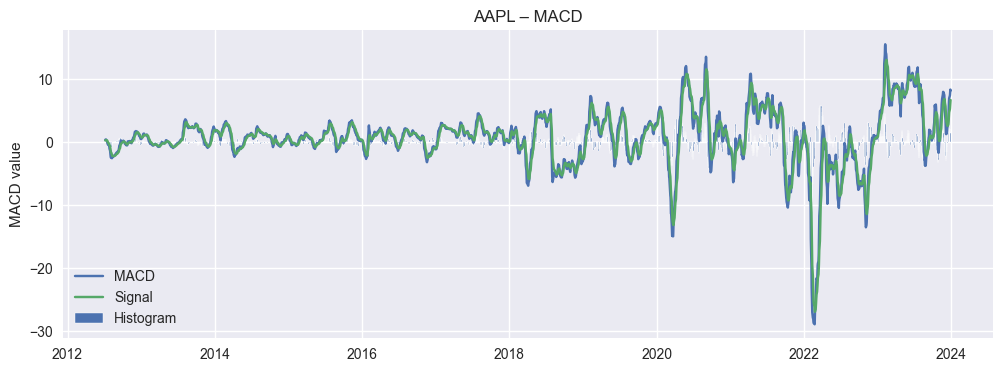

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["MACD"], label="MACD")
ax.plot(df.index, df["MACD_signal"], label="Signal")
ax.bar(df.index, df["MACD_hist"], label="Histogram")

ax.set_title("AAPL – MACD")
ax.set_ylabel("MACD value")
ax.legend()
plt.show()
